# Strategy Health Dashboard

Six automated checks against thresholds **decided before investing**.
Run this at every monthly rebalance. Takes ~30 seconds.

| Metric | Green | Amber | Red |
|--------|-------|-------|-----|
| Max Drawdown | Better than hist worst | Within 10% of worst | New all-time low |
| Rolling Sharpe 36m | > 0.7 | 0.5–0.7 | < 0.5 |
| Info Coefficient 12m | > 0.02 | 0–0.02 | Negative |
| Monthly Turnover | ≤ 1.5× avg | 1.5–2× avg | > 2× avg |
| Data Quality | 0 missing days | 1–4 missing | ≥ 5 or corrupted |
| ETF Availability | All present | 1 issue | Delisted/illiquid |


In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
warnings.filterwarnings('ignore')

from src.data import refresh_data, compute_returns
from src.signals import run_signal_pipeline
from src.health import (
    run_health_check, check_drawdown, check_rolling_sharpe,
    check_ic, check_turnover, check_data_quality, check_etf_availability,
    overall_verdict, GREEN, AMBER, RED
)

plt.rcParams.update({'figure.dpi':130,'font.size':10,
                     'axes.spines.top':False,'axes.spines.right':False})
print('Ready.')

Ready.


In [2]:
# Refresh data and recompute signals
prices  = refresh_data(proc_dir='../data/processed', config_path='../config/universe.yaml')
returns = compute_returns(prices)
signals = run_signal_pipeline(prices, returns, proc_dir='../data/processed')
print(f'Latest data: {prices.index[-1].date()}')

Data already up to date (2026-06-30).
Computing momentum signals ...
Saved 8 signal files -> ../data/processed/

Signal matrix: 258 month-ends x 15 tickers
Date range   : 2005-01-31 -> 2026-06-30

Latest month-end snapshot: 2026-06-30
Ticker      Score     3M%     6M%     12M%    Vol%  Eligible
------------------------------------------------------------
USO        0.3682  -17.3%   56.8%    46.5%   55.5%       YES
EEM        0.3423   24.6%   24.5%    43.9%   33.1%       YES
IWM        0.3078   24.9%   19.3%    40.0%   19.5%       YES
QQQ        0.2832   30.9%   17.3%    33.9%   23.4%       YES
SLV        0.2167  -15.6%  -24.6%    64.3%   52.2%        NO
SPY        0.1716   17.9%    8.2%    22.2%   14.0%       YES
DBC        0.1690   -8.7%   17.7%    26.7%   21.3%       YES
VGK        0.1335   12.0%    7.0%    17.7%   19.5%       YES
VNQ        0.1252   11.8%   11.1%    13.7%   15.4%       YES
GLD        0.0588  -10.8%  -11.2%    22.8%   23.9%        NO
TLT        0.0274    1.5%    1.1%

## Run All Health Checks

In [3]:
result  = run_health_check(signals, prices, returns, proc_dir='../data/processed')
checks  = result['checks']
verdict = result['verdict']


───────────────────────────────────────────────────────
Block A — Information Coefficient
───────────────────────────────────────────────────────
  N obs            : 11
  Mean IC          : 0.18149
  IC Std           : 0.49355
  ICIR (monthly)   : 0.3677
  ICIR (annual)    : 1.2738
  t-stat           : 1.2196
  p-value          : 0.250596  
  IC > 0           : 63.6%
  95% CI (boot)    : [-0.10585, 0.45455]
  Jarque-Bera p    : 0.6918  (normal-ish)
  Shapiro-Wilk p   : 0.4101
  Autocorr (lag-1) : 0.0965  (negligible)

  Annual IC (mean per year):
    2025: +0.4589  ███████████████████████████
    2026: -0.1514  █████████

  STRATEGY HEALTH DASHBOARD
  2026-06-30

  Metric                        Status      Value
  ────────────────────────────  ──────────  ──────────────────────────────
  Max Drawdown                  ● GREEN     -6.8%
                                            Threshold : Hist worst: -12.9%  |  Amber zone: -11.6%

  Rolling Sharpe (36m)          ● GREEN     1.137
  

## Visual Traffic-Light Dashboard


───────────────────────────────────────────────────────
Block A — Information Coefficient
───────────────────────────────────────────────────────
  N obs            : 245
  Mean IC          : 0.07241
  IC Std           : 0.40913
  ICIR (monthly)   : 0.1770
  ICIR (annual)    : 0.6131
  t-stat           : 2.7703
  p-value          : 0.006031  ***
  IC > 0           : 55.1%
  95% CI (boot)    : [0.02073, 0.12326]
  Jarque-Bera p    : 0.0140  (non-normal)
  Shapiro-Wilk p   : 0.0012
  Autocorr (lag-1) : 0.0125  (negligible)

  Annual IC (mean per year):
    2006: +0.1396  ████████
    2007: +0.0691  ████
    2008: +0.1397  ████████
    2009: +0.0244  █
    2010: +0.1555  █████████
    2011: +0.0652  ███
    2012: -0.0333  ██
    2013: +0.2199  █████████████
    2014: +0.1976  ███████████
    2015: +0.1741  ██████████
    2016: -0.2012  ████████████
    2017: +0.2229  █████████████
    2018: -0.0664  ███
    2019: -0.0226  █
    2020: +0.0988  █████
    2021: +0.0994  █████
    2022: +0.0

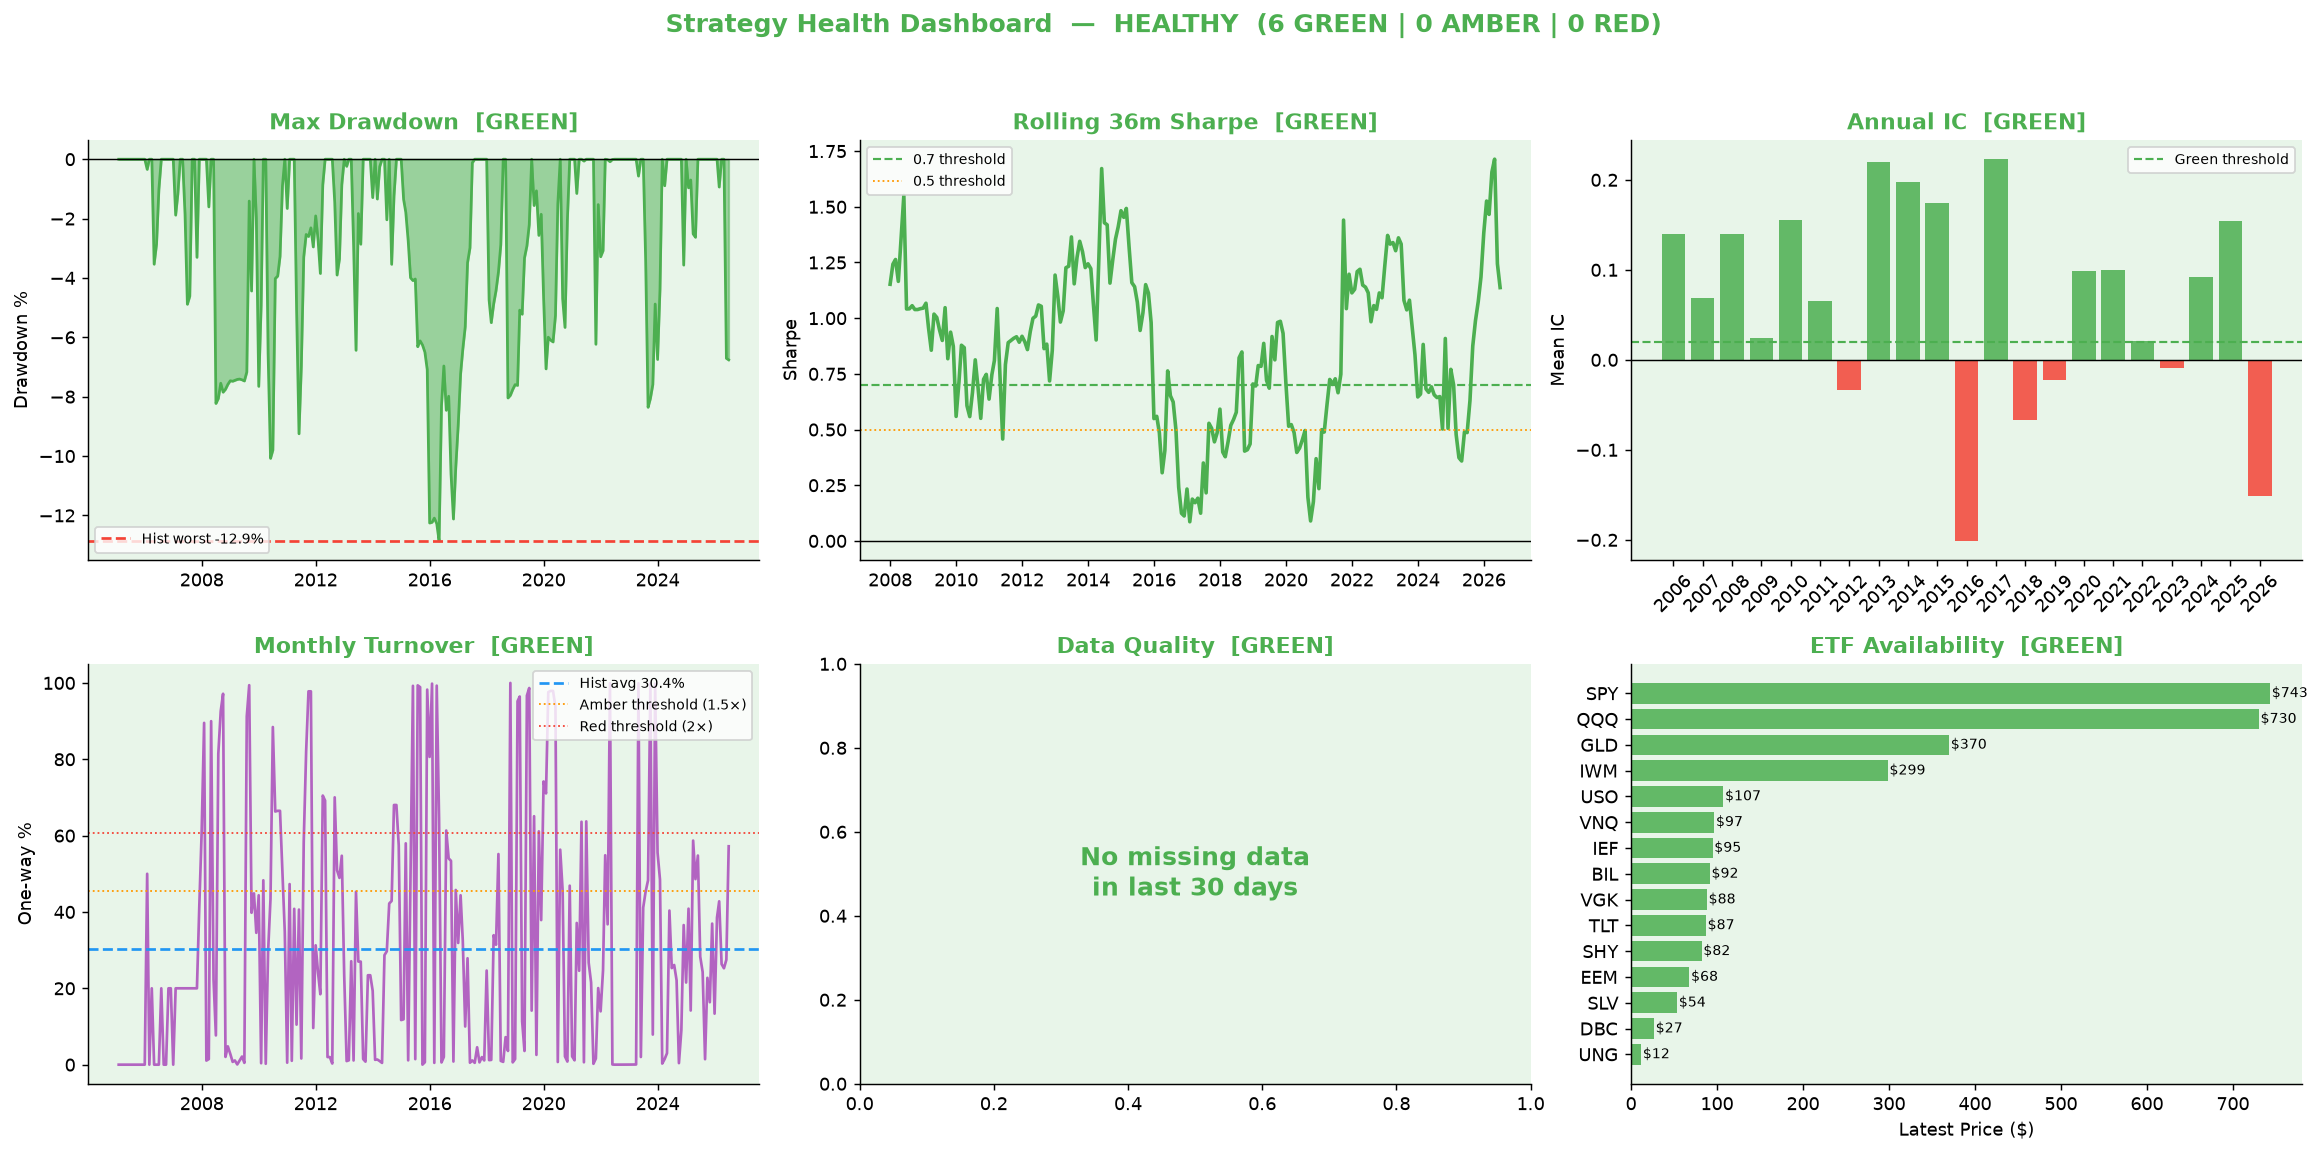

In [4]:
STATUS_COLORS = {GREEN: '#4CAF50', AMBER: '#FF9800', RED: '#F44336'}
STATUS_BG     = {GREEN: '#E8F5E9', AMBER: '#FFF3E0', RED: '#FFEBEE'}

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes_flat = axes.flatten()

from src.backtest import load_backtest_returns
from src.data import load_risk_free_rate
from src.portfolio import build_weight_matrix

bt       = load_backtest_returns('../data/processed')
hrp_ret  = bt['D: HRP'].dropna()
rf_daily = load_risk_free_rate('../data/processed')
rf_mo    = (1 + rf_daily).resample('ME').prod() - 1
me_ret   = prices.resample('ME').last().pct_change().dropna()
wdf      = build_weight_matrix(signals, me_ret, n_top=5, method='hrp')

eq = (1 + hrp_ret).cumprod()
dd = (eq / eq.cummax() - 1) * 100

# 1. Drawdown chart
ax = axes_flat[0]
c  = checks[0]
ax.set_facecolor(STATUS_BG[c['status']])
ax.fill_between(dd.index, dd.values, 0, alpha=0.5,
                color=STATUS_COLORS[c['status']])
ax.plot(dd.index, dd.values, color=STATUS_COLORS[c['status']], lw=1.5)
ax.axhline(c['raw']['hist_worst']*100, color='#F44336', lw=1.5, ls='--',
           label=f'Hist worst {c["raw"]["hist_worst"]*100:.1f}%')
ax.axhline(0, color='black', lw=0.8)
ax.set_title(f'Max Drawdown  [{c["status"]}]', fontweight='bold',
             color=STATUS_COLORS[c['status']])
ax.set_ylabel('Drawdown %'); ax.legend(fontsize=8)

# 2. Rolling Sharpe
ax = axes_flat[1]
c  = checks[1]
window = c['raw']['window']
roll_sh = []
roll_dt = []
for i in range(window, len(hrp_ret)+1):
    r   = hrp_ret.iloc[i-window:i]
    rf_ = rf_mo.reindex(r.index).fillna(0)
    n_yr = window/12
    cg = float((1+r).prod()**(1/n_yr)-1)
    vo = float(r.std()*12**0.5)
    sh = (cg - rf_.mean()*12) / vo if vo > 0 else float('nan')
    roll_sh.append(sh); roll_dt.append(hrp_ret.index[i-1])
ax.set_facecolor(STATUS_BG[c['status']])
ax.plot(roll_dt, roll_sh, color=STATUS_COLORS[c['status']], lw=2)
ax.axhline(0.7, color='#4CAF50', lw=1.2, ls='--', label='0.7 threshold')
ax.axhline(0.5, color='#FF9800', lw=1,   ls=':',  label='0.5 threshold')
ax.axhline(0,   color='black',   lw=0.8)
ax.set_title(f'Rolling {window}m Sharpe  [{c["status"]}]', fontweight='bold',
             color=STATUS_COLORS[c['status']])
ax.set_ylabel('Sharpe'); ax.legend(fontsize=8)

# 3. IC bar chart (annual)
ax = axes_flat[2]
c  = checks[2]
from src.stats_validation import ic_full_analysis
from src.hypothesis_tests import compute_me_forward_returns
fwd    = compute_me_forward_returns(prices)
ic_res = ic_full_analysis(signals, fwd)
ic_ser = ic_res.get('ic_series', pd.Series(dtype=float))
ann_ic = ic_ser.groupby(ic_ser.index.year).mean()
bar_colors = [STATUS_COLORS[GREEN] if v > 0.02 else
              STATUS_COLORS[AMBER] if v > 0 else
              STATUS_COLORS[RED] for v in ann_ic.values]
ax.set_facecolor(STATUS_BG[c['status']])
ax.bar(ann_ic.index.astype(str), ann_ic.values, color=bar_colors, alpha=0.85)
ax.axhline(0, color='black', lw=0.8)
ax.axhline(0.02, color='#4CAF50', lw=1.2, ls='--', label='Green threshold')
ax.set_title(f'Annual IC  [{c["status"]}]', fontweight='bold',
             color=STATUS_COLORS[c['status']])
ax.set_ylabel('Mean IC'); ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=45)

# 4. Turnover
ax = axes_flat[3]
c  = checks[3]
monthly_to = wdf.diff().abs().sum(axis=1) / 2 * 100
ax.set_facecolor(STATUS_BG[c['status']])
ax.plot(monthly_to.index, monthly_to.values, color='#9C27B0', lw=1.5, alpha=0.7)
ax.axhline(c['raw']['hist_avg']*100, color='#2196F3', lw=1.5, ls='--',
           label=f'Hist avg {c["raw"]["hist_avg"]*100:.1f}%')
ax.axhline(c['raw']['hist_avg']*150, color='#FF9800', lw=1, ls=':',
           label='Amber threshold (1.5×)')
ax.axhline(c['raw']['hist_avg']*200, color='#F44336', lw=1, ls=':',
           label='Red threshold (2×)')
ax.set_title(f'Monthly Turnover  [{c["status"]}]', fontweight='bold',
             color=STATUS_COLORS[c['status']])
ax.set_ylabel('One-way %'); ax.legend(fontsize=8)

# 5. Data quality — missing heatmap
ax = axes_flat[4]
c  = checks[4]
miss_30 = prices.iloc[-30:].isna().astype(int)
if miss_30.values.sum() == 0:
    ax.set_facecolor(STATUS_BG[GREEN])
    ax.text(0.5, 0.5, 'No missing data\nin last 30 days',
            ha='center', va='center', transform=ax.transAxes,
            fontsize=14, fontweight='bold', color=STATUS_COLORS[GREEN])
else:
    ax.set_facecolor(STATUS_BG[c['status']])
    im = ax.imshow(miss_30.T.values, aspect='auto', cmap='RdYlGn_r',
                   vmin=0, vmax=1)
    ax.set_yticks(range(len(miss_30.columns)))
    ax.set_yticklabels(miss_30.columns, fontsize=7)
ax.set_title(f'Data Quality  [{c["status"]}]', fontweight='bold',
             color=STATUS_COLORS[c['status']])

# 6. ETF availability — latest prices
ax = axes_flat[5]
c  = checks[5]
latest = prices.ffill().iloc[-1].sort_values(ascending=True)
bar_c  = [STATUS_COLORS[GREEN] if v > 0 else STATUS_COLORS[RED] for v in latest.values]
ax.set_facecolor(STATUS_BG[c['status']])
ax.barh(latest.index, latest.values, color=bar_c, alpha=0.85)
ax.set_xlabel('Latest Price ($)')
ax.set_title(f'ETF Availability  [{c["status"]}]', fontweight='bold',
             color=STATUS_COLORS[c['status']])
for i, (tkr, price) in enumerate(latest.items()):
    ax.text(price+2, i, f'${price:.0f}', va='center', fontsize=7.5)

# Overall verdict banner
n_green = sum(1 for ch in checks if ch['status']==GREEN)
n_amber = sum(1 for ch in checks if ch['status']==AMBER)
n_red   = sum(1 for ch in checks if ch['status']==RED)
v_color = STATUS_COLORS[RED] if n_red>0 else STATUS_COLORS[AMBER] if n_amber>0 else STATUS_COLORS[GREEN]
fig.suptitle(
    f'Strategy Health Dashboard  —  {verdict}  '
    f'({n_green} GREEN | {n_amber} AMBER | {n_red} RED)',
    fontsize=14, fontweight='bold', color=v_color
)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

## Operating Manual

In [5]:
print('=' * 68)
print('  OPERATING MANUAL')
print('=' * 68)
print()
print('  EVERY MONTH (20-30 min)')
print('  1. Open notebooks/18_rebalancing.ipynb')
print('     - Data refreshes automatically (refresh_data)')
print('     - Signals recomputed on fresh prices')
print('     - Live prices fetched via yfinance')
print('  2. Open notebooks/19_health_dashboard.ipynb (this notebook)')
print('     - Review traffic-light status')
print('     - If any RED: investigate before trading')
print('     - If all GREEN: proceed')
print('  3. Execute the trade sheet from notebook 18')
print('     - Sell orders first, then buy orders')
print('     - Log trades in a spreadsheet (date, ETF, shares, price)')
print()
print('  EVERY QUARTER (1 hour)')
print('  4. Review rolling Sharpe trend (is it stable, improving, declining?)')
print('  5. Review max drawdown vs historical worst')
print('  6. Review turnover — is it drifting higher? Why?')
print('  7. Check for ETF corporate actions (splits, mergers, delistings)')
print()
print('  EVERY YEAR (half a day)  — run notebooks/17_governance.ipynb')
print('  8.  Re-run IC analysis  (notebook 07)')
print('  9.  Re-run bootstrap    (notebook 07)')
print('  10. Re-run walk-forward (notebook 08)')
print('  11. Re-run governance checklist (notebook 17)')
print('  12. Compare live Sharpe vs backtest Sharpe')
print('       — If live Sharpe < 0.5 for 2+ years: stop and review')
print('       — If live matches backtest: increase position size')
print()
print('  WHEN TO STOP')
print('  - Rolling Sharpe (36m) < 0.5 for 6+ consecutive months  → RED')
print('  - Drawdown exceeds historical worst by > 10%             → RED')
print('  - IC negative for 2+ consecutive quarters                → RED')
print('  - ETF delisted with no suitable replacement              → PAUSE')
print('  - Annual governance check produces a NO-GO               → STOP')
print()
print('  RULE: Thresholds are set once, before investing.')
print('        They are never moved to avoid triggering an alert.')
print('=' * 68)

  OPERATING MANUAL

  EVERY MONTH (20-30 min)
  1. Open notebooks/18_rebalancing.ipynb
     - Data refreshes automatically (refresh_data)
     - Signals recomputed on fresh prices
     - Live prices fetched via yfinance
  2. Open notebooks/19_health_dashboard.ipynb (this notebook)
     - Review traffic-light status
     - If any RED: investigate before trading
     - If all GREEN: proceed
  3. Execute the trade sheet from notebook 18
     - Sell orders first, then buy orders
     - Log trades in a spreadsheet (date, ETF, shares, price)

  EVERY QUARTER (1 hour)
  4. Review rolling Sharpe trend (is it stable, improving, declining?)
  5. Review max drawdown vs historical worst
  6. Review turnover — is it drifting higher? Why?
  7. Check for ETF corporate actions (splits, mergers, delistings)

  EVERY YEAR (half a day)  — run notebooks/17_governance.ipynb
  8.  Re-run IC analysis  (notebook 07)
  9.  Re-run bootstrap    (notebook 07)
  10. Re-run walk-forward (notebook 08)
  11. Re-run g

## Current Dashboard Status

The cell below prints a compact summary suitable for copying into an investment log.

In [6]:
from datetime import datetime
today = datetime.now().strftime('%Y-%m-%d')
print(f'--- Monthly Health Check: {today} ---')
for c in checks:
    icon = {'GREEN':'[G]','AMBER':'[A]','RED':'[R]'}[c['status']]
    print(f'{icon} {c["metric"]:<28} {c["value"]}')
print(f'VERDICT: {verdict}')
print('Actions taken: ')
for c in checks:
    if c['status'] != 'GREEN':
        print(f'  - {c["metric"]}: {c["action"]}')

--- Monthly Health Check: 2026-06-30 ---
[G] Max Drawdown                 -6.8%
[G] Rolling Sharpe (36m)         1.137
[G] Info Coefficient (12m)       0.1815
[G] Monthly Turnover             36.6%/mo (recent)  vs  30.4%/mo (hist avg)
[G] Data Quality                 No issues
[G] ETF Availability             All 15 ETFs available
VERDICT: HEALTHY
Actions taken: 
